<a href="https://colab.research.google.com/github/maiaragoudapatil-art/Shopper-Spectrum-Customer-Segmentation-and-Product-Recommendations-in-E-Commerce/blob/main/Shopper_Spectrum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pymongo pandas scikit-learn matplotlib seaborn plotly --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 14.6 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

import pymongo
from pymongo import MongoClient

import warnings
warnings.filterwarnings('ignore')

print(' All libraries imported successfully')

 All libraries imported successfully


In [4]:
from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename, encoding='latin1')

print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print('\nColumn names:', df.columns.tolist())
print('\nFirst 3 rows:')
df.head(3)

Saving online_retail (1).csv to online_retail (1).csv
Loaded: 541,909 rows × 8 columns

Column names: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

First 3 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom


In [5]:
print('=== BEFORE CLEANING ===')
print(f'Total rows          : {len(df):,}')
print(f'Null CustomerIDs    : {df["CustomerID"].isna().sum():,}')
print(f'Negative Quantities : {(df["Quantity"] < 0).sum():,}')
print(f'Zero/Neg UnitPrice  : {(df["UnitPrice"] <= 0).sum():,}')


=== BEFORE CLEANING ===
Total rows          : 541,909
Null CustomerIDs    : 135,080
Negative Quantities : 10,624
Zero/Neg UnitPrice  : 2,517


In [6]:
#Separate InvoiceNo types
df['InvoiceNo'] = df['InvoiceNo'].astype(str)
df['is_cancelled'] = df['InvoiceNo'].str.startswith('C')

cancelled_df = df[df['is_cancelled']].copy()   # 9,291 rows — for return analysis later
df_clean     = df[~df['is_cancelled']].copy()  # normal orders only

print(f'\nCancelled invoices separated : {len(cancelled_df):,}')


Cancelled invoices separated : 9,288


In [7]:
#Separate CustomerID types -
df_clean['CustomerID'] = df_clean['CustomerID'].astype(str)
df_clean['cust_type']  = df_clean['CustomerID'].apply(
    lambda x: 'guest' if x in ['nan', 'NaN', ''] else 'registered'
)

guest_df = df_clean[df_clean['cust_type'] == 'guest'].copy()
df_clean = df_clean[df_clean['cust_type'] == 'registered'].copy()

In [8]:
## Clean CustomerID — remove '.0' float suffix
df_clean['CustomerID'] = df_clean['CustomerID'].str.replace('.0', '', regex=False)

In [9]:
# Remove bad quantities & prices
df_clean = df_clean[df_clean['Quantity']  > 0]
df_clean = df_clean[df_clean['UnitPrice'] > 0]

# Parse data
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

In [10]:
# TotalValue feature
df_clean['TotalValue'] = df_clean['Quantity'] * df_clean['UnitPrice']

print('\n=== AFTER CLEANING ===')
print(f'Registered orders   : {len(df_clean):,}')
print(f'Unique customers    : {df_clean["CustomerID"].nunique():,}')
print(f'Date range          : {df_clean["InvoiceDate"].min().date()} → {df_clean["InvoiceDate"].max().date()}')
print('\n Cleaning complete')


=== AFTER CLEANING ===
Registered orders   : 397,884
Unique customers    : 4,338
Date range          : 2022-12-01 → 2023-12-09

 Cleaning complete


In [11]:
# Group products per customer with price stats
cust_product_map = (
    df_clean.groupby('CustomerID')
    .agg(
        products_bought = ('Description', lambda x: list(x.dropna().unique())),
        num_products    = ('Description', 'nunique'),
        max_unit_price  = ('UnitPrice', 'max'),
        min_unit_price  = ('UnitPrice', 'min'),
        total_spent     = ('TotalValue', 'sum'),
        country         = ('Country', lambda x: x.mode()[0])
    )
    .reset_index()
)

print(f'Customer-product map: {len(cust_product_map):,} customers')
cust_product_map.head(3)

Customer-product map: 4,338 customers


,CustomerID,products_bought,num_products,max_unit_price,min_unit_price,total_spent,country
0,12346,[MEDIUM CERAMIC TOP STORAGE JAR],1,1.04,1.04,77183.60,United Kingdom
1,12347,"[BLACK CANDELABRA T-LIGHT HOLDER, AIRLINE BAG ...",103,12.75,0.25,4310.00,Iceland
2,12348,"[72 SWEETHEART FAIRY CAKE CASES, 60 CAKE CASES...",22,40.00,0.29,1797.24,Finland


RFM Feature Engineering



In [12]:
# Snapshot date = 1 day after last invoice
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Snapshot date: {snapshot_date.date()}')

rfm = (
    df_clean.groupby('CustomerID')
    .agg(
        Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
        Frequency = ('InvoiceNo',   'nunique'),
        Monetary  = ('TotalValue',  'sum')
    )
    .reset_index()
)

print(f'\nRFM table: {len(rfm):,} customers')
print('\nRFM stats:')
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))
rfm.head(5)

Snapshot date: 2023-12-10

RFM table: 4,338 customers

RFM stats:
       Recency  Frequency   Monetary
count  4338.00    4338.00    4338.00
mean     92.54       4.27    2054.27
std     100.01       7.70    8989.23
min       1.00       1.00       3.75
25%      18.00       1.00     307.41
50%      51.00       2.00     674.48
75%     142.00       5.00    1661.74
max     374.00     209.00  280206.02


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


RFM Distribution Plots

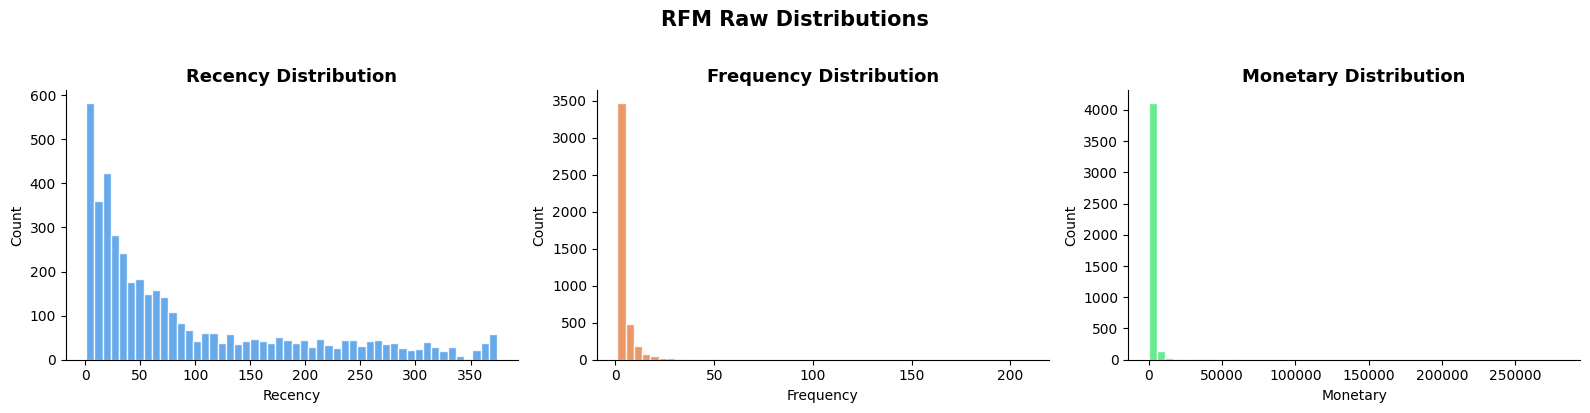

 Saved rfm_distributions.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = ['#4C9BE8', '#E8864C', '#4CE87A']

for ax, col, color in zip(axes, ['Recency', 'Frequency', 'Monetary'], colors):
    ax.hist(rfm[col], bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{col} Distribution', fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('RFM Raw Distributions', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('rfm_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved rfm_distributions.png')

Scale RFm for Clustring


In [14]:
# Log-transform Monetary to reduce skew, then StandardScale all 3
rfm_scaled = rfm.copy()
rfm_scaled['Monetary'] = np.log1p(rfm_scaled['Monetary'])

scaler = StandardScaler()
X = scaler.fit_transform(rfm_scaled[['Recency', 'Frequency', 'Monetary']])

print('Scaled feature array shape:', X.shape)
print('Mean of each feature (should be ≈ 0):', X.mean(axis=0).round(4))
print('Std  of each feature (should be ≈ 1):', X.std(axis=0).round(4))
print('\nScaling complete')

Scaled feature array shape: (4338, 3)
Mean of each feature (should be ≈ 0): [0. 0. 0.]
Std  of each feature (should be ≈ 1): [1. 1. 1.]

Scaling complete


Elbow Method - K optmial

In [15]:
inertia_list    = []
silhouette_list = []
db_list         = []
K_range         = range(2, 11)

print('Testing K values...')
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X)

    inertia_list.append(km.inertia_)
    silhouette_list.append(silhouette_score(X, labels))
    db_list.append(davies_bouldin_score(X, labels))
    print(f'  K={k} | Inertia={km.inertia_:,.1f} | Silhouette={silhouette_list[-1]:.4f} | DB={db_list[-1]:.4f}')

print('\n Done — plotting below')

Testing K values...
  K=2 | Inertia=8,551.8 | Silhouette=0.3722 | DB=1.0417
  K=3 | Inertia=5,981.7 | Silhouette=0.4226 | DB=0.8557
  K=4 | Inertia=4,198.1 | Silhouette=0.4172 | DB=0.7622
  K=5 | Inertia=3,236.1 | Silhouette=0.4084 | DB=0.7381
  K=6 | Inertia=2,742.2 | Silhouette=0.3648 | DB=0.7911
  K=7 | Inertia=2,352.1 | Silhouette=0.3578 | DB=0.7279
  K=8 | Inertia=1,987.4 | Silhouette=0.3510 | DB=0.7660
  K=9 | Inertia=1,774.1 | Silhouette=0.3519 | DB=0.7618
  K=10 | Inertia=1,604.4 | Silhouette=0.3264 | DB=0.8083

 Done — plotting below


PLot Elbow + Silhouette + Davies Bouldin

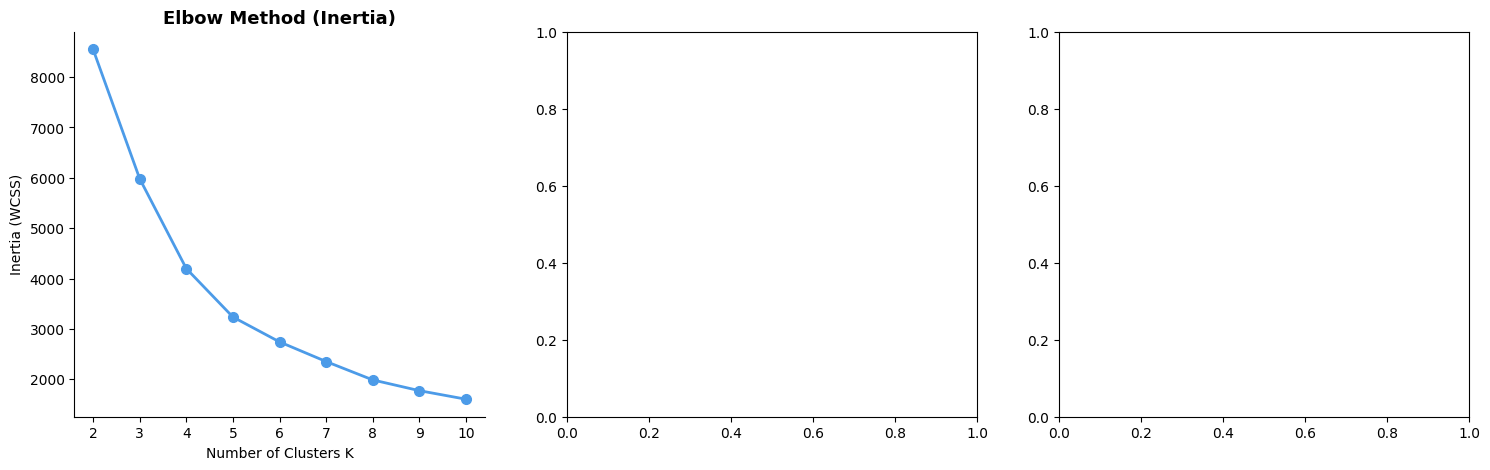

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#  Elbow
axes[0].plot(K_range, inertia_list, 'o-', color='#4C9BE8', linewidth=2, markersize=7)
axes[0].set_title('Elbow Method (Inertia)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters K')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)


In [17]:
#Silhouette
axes[1].plot(K_range, silhouette_list, 'o-', color='#4CE87A', linewidth=2, markersize=7)
best_k_sil = list(K_range)[silhouette_list.index(max(silhouette_list))]
axes[1].axvline(best_k_sil, color='red', linestyle='--', alpha=0.7, label=f'Best K={best_k_sil}')
axes[1].set_title('Silhouette Score (higher = better)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters K')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)


In [18]:
#Davies-Bouldin
axes[2].plot(K_range, db_list, 'o-', color='#E8864C', linewidth=2, markersize=7)
best_k_db = list(K_range)[db_list.index(min(db_list))]
axes[2].axvline(best_k_db, color='red', linestyle='--', alpha=0.7, label=f'Best K={best_k_db}')
axes[2].set_title('Davies-Bouldin Score (lower = better)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Number of Clusters K')
axes[2].set_ylabel('DB Score')
axes[2].legend()
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)


In [19]:
plt.suptitle('Optimal K Selection', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

In [20]:

print(f'\n Silhouette suggests K = {best_k_sil}')
print(f' Davies-Bouldin suggests K = {best_k_db}')
print(' Pick the K where elbow bends AND scores agree — typically K=4 for retail RFM')


 Silhouette suggests K = 3
 Davies-Bouldin suggests K = 7
 Pick the K where elbow bends AND scores agree — typically K=4 for retail RFM


Final Kmeans with chosen k

In [21]:
# Change this based on your elbow + silhouette output above
OPTIMAL_K = 4

final_km = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=42)
rfm['Cluster'] = final_km.fit_predict(X)

print(f'KMeans fitted with K = {OPTIMAL_K}')
print(f'\nFinal Silhouette Score : {silhouette_score(X, rfm["Cluster"]):.4f}')
print(f'Final Davies-Bouldin   : {davies_bouldin_score(X, rfm["Cluster"]):.4f}')
print('\nCluster sizes:')
print(rfm['Cluster'].value_counts().sort_index())

KMeans fitted with K = 4

Final Silhouette Score : 0.4172
Final Davies-Bouldin   : 0.7622

Cluster sizes:
Cluster
0    2059
1    1004
2    1253
3      22
Name: count, dtype: int64


In [22]:
# Compute mean RFM per cluster to understand what each cluster represents
cluster_summary = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(2)
cluster_summary['Size'] = rfm.groupby('Cluster').size()

print('Cluster Profile:')
print(cluster_summary.to_string())

Cluster Profile:
         Recency  Frequency  Monetary  Size
Cluster                                    
0          52.95       2.20    586.88  2059
1         253.37       1.46    408.62  1004
2          30.24       8.65   4471.95  1253
3           5.77      77.45  76791.63    22


In [23]:
cluster_summary['score'] = (
    cluster_summary['Recency'].rank(ascending=True) +
    cluster_summary['Monetary'].rank(ascending=False) +
    cluster_summary['Frequency'].rank(ascending=False)
)
ranked = cluster_summary['score'].sort_values().index.tolist()

segment_labels = {
    ranked[0]: 'Champions',
    ranked[1]: 'Loyal Customers',
    ranked[2]: 'At-Risk',
    ranked[3]: 'Lost / Passive'
}

rfm['Segment'] = rfm['Cluster'].map(segment_labels)

print('\nSegment labels assigned:')
print(rfm[['CustomerID','Recency','Frequency','Monetary','Cluster','Segment']].head(8).to_string(index=False))


Segment labels assigned:
CustomerID  Recency  Frequency  Monetary  Cluster         Segment
     12346      326          1  77183.60        2 Loyal Customers
     12347        2          7   4310.00        2 Loyal Customers
     12348       75          4   1797.24        2 Loyal Customers
     12349       19          1   1757.55        2 Loyal Customers
     12350      310          1    334.40        1  Lost / Passive
     12352       36          8   2506.04        2 Loyal Customers
     12353      204          1     89.00        1  Lost / Passive
     12354      232          1   1079.40        1  Lost / Passive


Visualise Clusters

In [24]:
# 3D scatter: Recency vs Frequency vs Monetary
fig = px.scatter_3d(
    rfm,
    x='Recency', y='Frequency', z='Monetary',
    color='Segment',
    title='Customer Segments — 3D RFM Space',
    opacity=0.6,
    color_discrete_map={
        'Champions'     : '#2ECC71',
        'Loyal Customers': '#3498DB',
        'At-Risk'       : '#E67E22',
        'Lost / Passive': '#E74C3C'
    }
)
fig.update_layout(height=600)
fig.write_html('cluster_3d.html')
fig.show()
print('Saved cluster_3d.html')

Saved cluster_3d.html


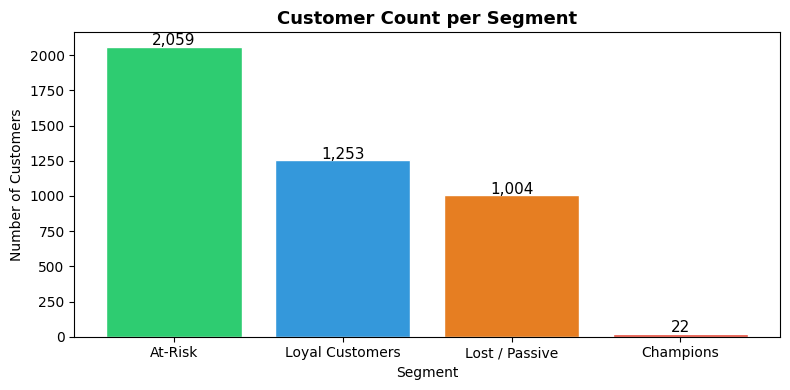

In [25]:
# Segment size bar chart
seg_counts = rfm['Segment'].value_counts()
plt.figure(figsize=(8, 4))
bars = plt.bar(seg_counts.index, seg_counts.values,
               color=['#2ECC71','#3498DB','#E67E22','#E74C3C'],
               edgecolor='white')
for bar, val in zip(bars, seg_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{val:,}', ha='center', fontsize=11)
plt.title('Customer Count per Segment', fontsize=13, fontweight='bold')
plt.ylabel('Number of Customers')
plt.xlabel('Segment')
plt.tight_layout()
plt.savefig('segment_counts.png', dpi=150, bbox_inches='tight')
plt.show()


In [26]:
# Radar / spider chart per segment
seg_means = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()
# Normalise 0-1 for radar
seg_norm = (seg_means - seg_means.min()) / (seg_means.max() - seg_means.min())

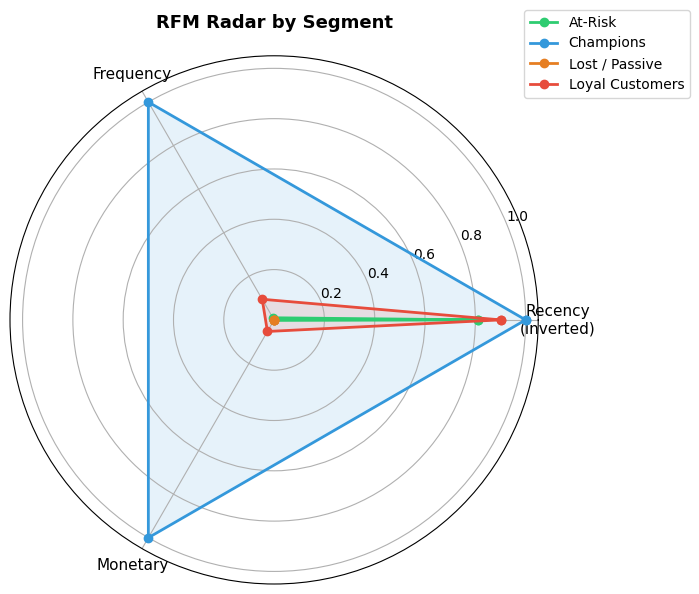

All charts saved


In [27]:
# Recency is inverted — lower is better
seg_norm['Recency'] = 1 - seg_norm['Recency']

categories = ['Recency\n(inverted)', 'Frequency', 'Monetary']
colors_radar = ['#2ECC71','#3498DB','#E67E22','#E74C3C']

fig_r, ax_r = plt.subplots(1, 1, figsize=(7, 6), subplot_kw=dict(polar=True))
angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

for i, (seg, row) in enumerate(seg_norm.iterrows()):
    vals = row.tolist() + [row.tolist()[0]]
    ax_r.plot(angles, vals, 'o-', linewidth=2, label=seg, color=colors_radar[i])
    ax_r.fill(angles, vals, alpha=0.12, color=colors_radar[i])

ax_r.set_xticks(angles[:-1])
ax_r.set_xticklabels(categories, fontsize=11)
ax_r.set_title('RFM Radar by Segment', fontsize=13, fontweight='bold', pad=20)
ax_r.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('rfm_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print('All charts saved')

In [28]:
# This cell was attempting to connect to MongoDB, but was encountering persistent SSL handshake issues.
# The MongoDB connection is now handled in cell '7MWEqHLXSeA9' with a more robust SSL configuration.
# Please proceed to cell '7MWEqHLXSeA9' to establish the connection after ensuring its URI is correct.

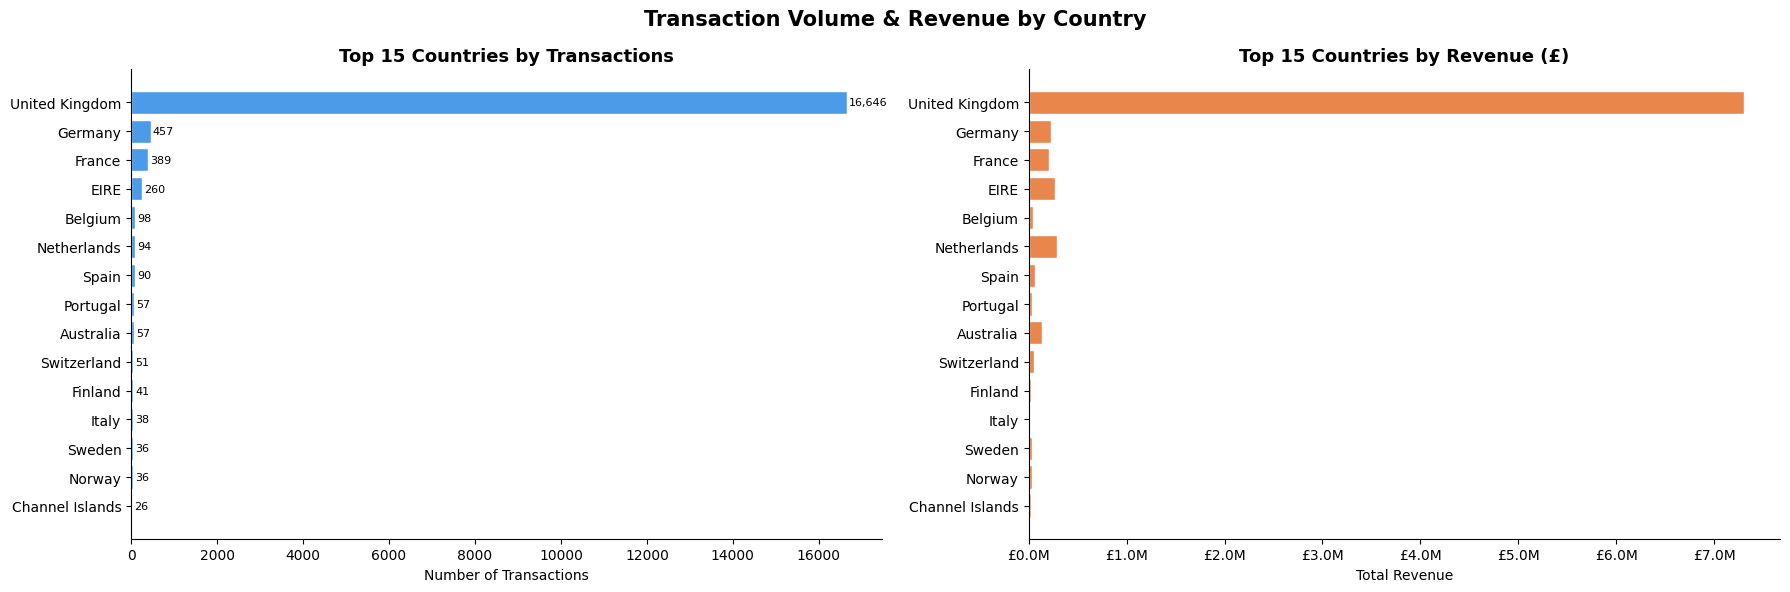

        Country  Transactions     Revenue  Customers
 United Kingdom         16646 7308391.554       3920
        Germany           457  228867.140         94
         France           389  209024.050         87
           EIRE           260  265545.900          3
        Belgium            98   41196.340         25
    Netherlands            94  285446.340          9
          Spain            90   61577.110         30
       Portugal            57   33439.890         19
      Australia            57  138521.310          9
    Switzerland            51   56443.950         21
        Finland            41   22546.080         12
          Italy            38   17483.240         14
         Sweden            36   38378.330          8
         Norway            36   36165.440         10
Channel Islands            26   20450.440          9

Saved eda_country.png


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

# ── Country transaction volume ──────────────────────────────────────────────
country_txn = (
    df_clean.groupby('Country')
    .agg(Transactions=('InvoiceNo','nunique'),
         Revenue=('TotalValue','sum'),
         Customers=('CustomerID','nunique'))
    .sort_values('Transactions', ascending=False)
    .head(15)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Transactions bar
bars = axes[0].barh(country_txn['Country'][::-1], country_txn['Transactions'][::-1],
                    color='#4C9BE8', edgecolor='white')
axes[0].set_title('Top 15 Countries by Transactions', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Transactions')
for bar in bars:
    w = bar.get_width()
    axes[0].text(w + 50, bar.get_y() + bar.get_height()/2,
                 f'{int(w):,}', va='center', fontsize=8)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Revenue bar
axes[1].barh(country_txn['Country'][::-1], country_txn['Revenue'][::-1],
             color='#E8864C', edgecolor='white')
axes[1].set_title('Top 15 Countries by Revenue (£)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Revenue')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Transaction Volume & Revenue by Country', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_country.png', dpi=150, bbox_inches='tight')
plt.show()

print(country_txn[['Country','Transactions','Revenue','Customers']].to_string(index=False))
print('\nSaved eda_country.png')

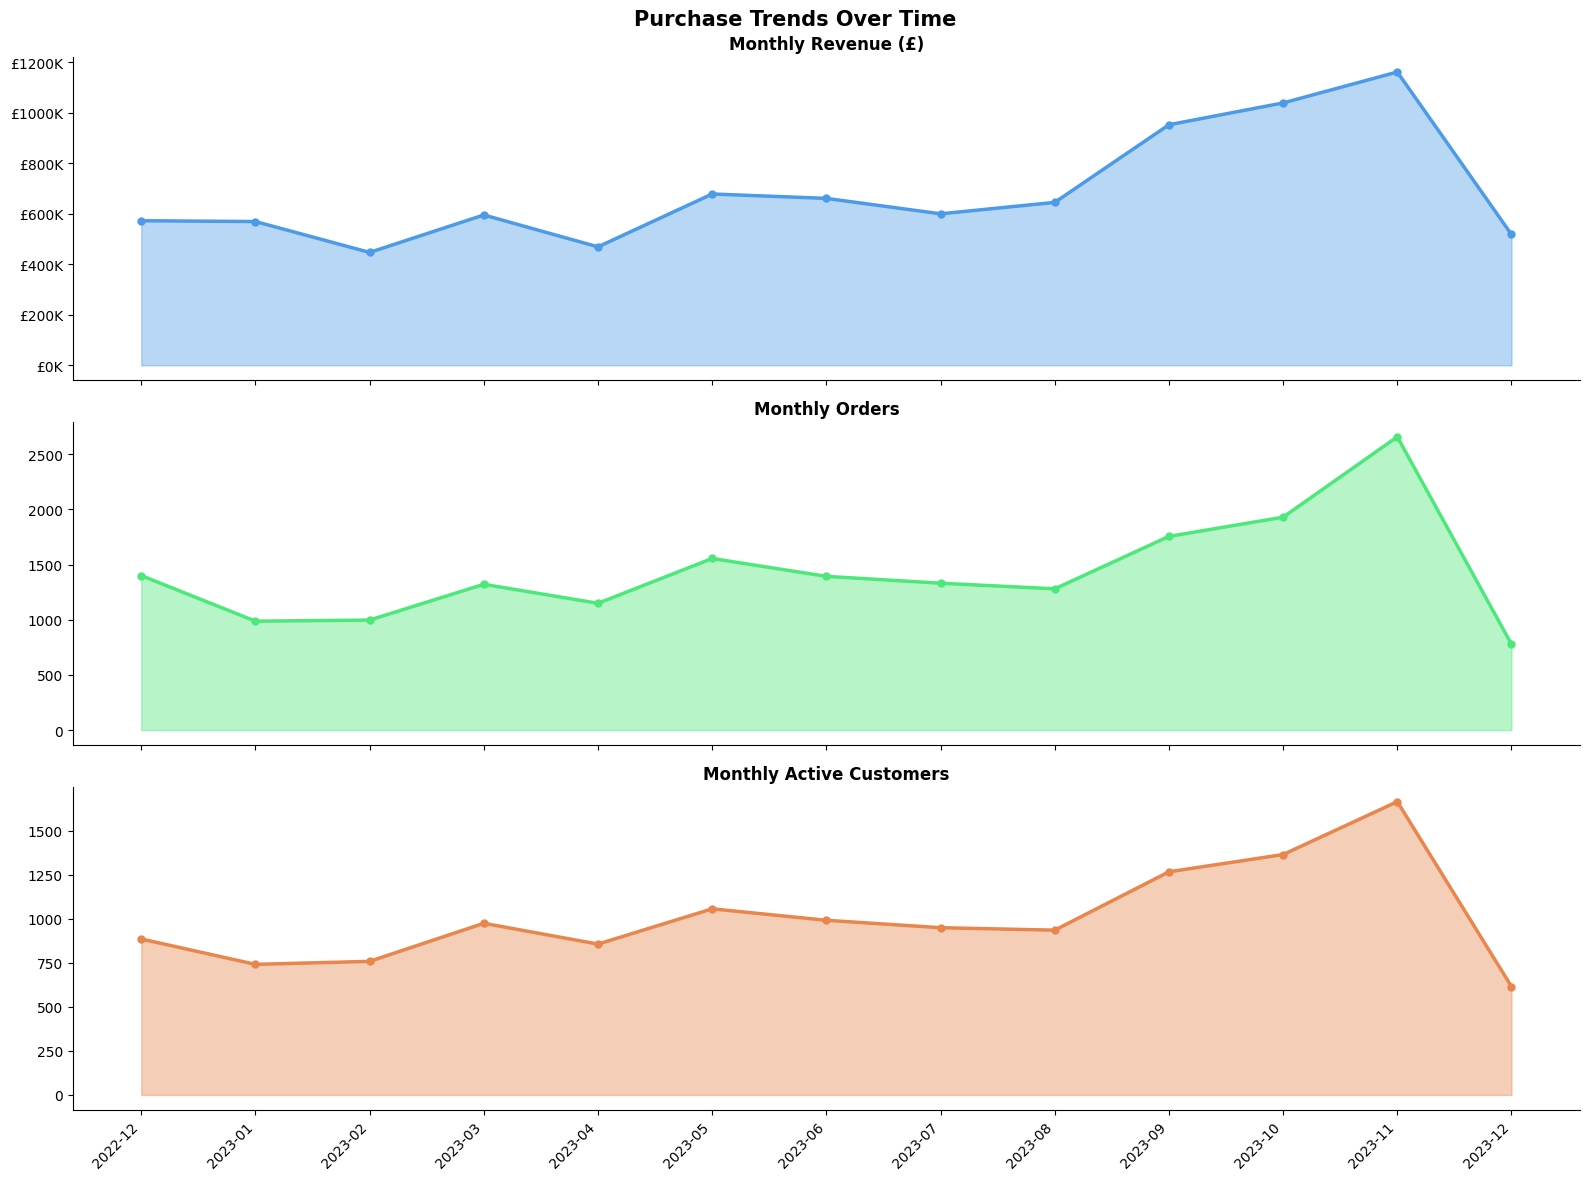

✅ Saved eda_trends.png


In [30]:
# ── Monthly revenue + order count trend ─────────────────────────────────────
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

monthly = (
    df_clean.groupby('YearMonth')
    .agg(Revenue=('TotalValue','sum'),
         Orders=('InvoiceNo','nunique'),
         Customers=('CustomerID','nunique'))
    .reset_index()
)
monthly['YearMonth_str'] = monthly['YearMonth'].astype(str)

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

axes[0].fill_between(monthly['YearMonth_str'], monthly['Revenue'],
                     alpha=0.4, color='#4C9BE8')
axes[0].plot(monthly['YearMonth_str'], monthly['Revenue'],
             color='#4C9BE8', linewidth=2.5, marker='o', markersize=5)
axes[0].set_title('Monthly Revenue (£)', fontsize=12, fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

axes[1].fill_between(monthly['YearMonth_str'], monthly['Orders'],
                     alpha=0.4, color='#4CE87A')
axes[1].plot(monthly['YearMonth_str'], monthly['Orders'],
             color='#4CE87A', linewidth=2.5, marker='o', markersize=5)
axes[1].set_title('Monthly Orders', fontsize=12, fontweight='bold')
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

axes[2].fill_between(monthly['YearMonth_str'], monthly['Customers'],
                     alpha=0.4, color='#E8864C')
axes[2].plot(monthly['YearMonth_str'], monthly['Customers'],
             color='#E8864C', linewidth=2.5, marker='o', markersize=5)
axes[2].set_title('Monthly Active Customers', fontsize=12, fontweight='bold')
axes[2].spines['top'].set_visible(False); axes[2].spines['right'].set_visible(False)
plt.xticks(rotation=45, ha='right')

plt.suptitle('Purchase Trends Over Time', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved eda_trends.png')

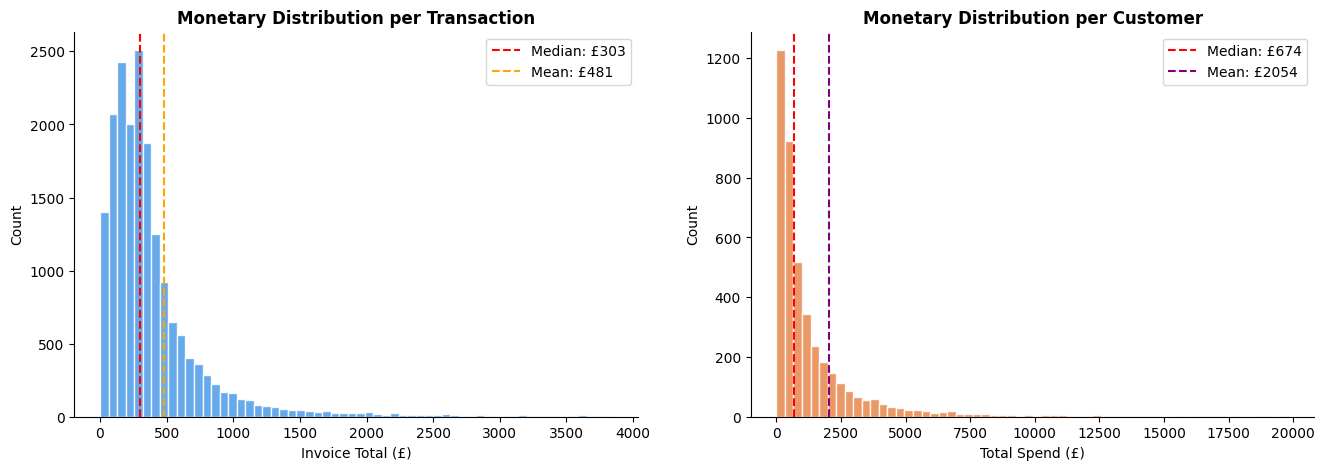

In [31]:
# Monetary distribution
invoice_total = df_clean.groupby('InvoiceNo')['TotalValue'].sum()
customer_total = df_clean.groupby('CustomerID')['TotalValue'].sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Cap at 99th percentile to remove extreme outliers for readability
cap_inv = invoice_total.quantile(0.99)
cap_cust = customer_total.quantile(0.99)

axes[0].hist(invoice_total[invoice_total <= cap_inv], bins=60,
             color='#4C9BE8', edgecolor='white', alpha=0.85)
axes[0].axvline(invoice_total.median(), color='red', linestyle='--',
                label=f'Median: £{invoice_total.median():.0f}')
axes[0].axvline(invoice_total.mean(), color='orange', linestyle='--',
                label=f'Mean: £{invoice_total.mean():.0f}')
axes[0].set_title('Monetary Distribution per Transaction', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Invoice Total (£)'); axes[0].set_ylabel('Count')
axes[0].legend(); axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

axes[1].hist(customer_total[customer_total <= cap_cust], bins=60,
             color='#E8864C', edgecolor='white', alpha=0.85)
axes[1].axvline(customer_total.median(), color='red', linestyle='--',
                label=f'Median: £{customer_total.median():.0f}')
axes[1].axvline(customer_total.mean(), color='purple', linestyle='--',
                label=f'Mean: £{customer_total.mean():.0f}')
axes[1].set_title('Monetary Distribution per Customer', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Spend (£)'); axes[1].set_ylabel('Count')
axes[1].legend(); axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)



In [32]:
plt.suptitle('Spending Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_monetary.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Per-Transaction  → Median: £{invoice_total.median():.2f} | Mean: £{invoice_total.mean():.2f} | Max: £{invoice_total.max():.2f}')
print(f'Per-Customer     → Median: £{customer_total.median():.2f} | Mean: £{customer_total.mean():.2f} | Max: £{customer_total.max():.2f}')
print('Saved eda_monetary.png')

<Figure size 640x480 with 0 Axes>

Per-Transaction  → Median: £303.04 | Mean: £480.87 | Max: £168469.60
Per-Customer     → Median: £674.49 | Mean: £2054.27 | Max: £280206.02
Saved eda_monetary.png


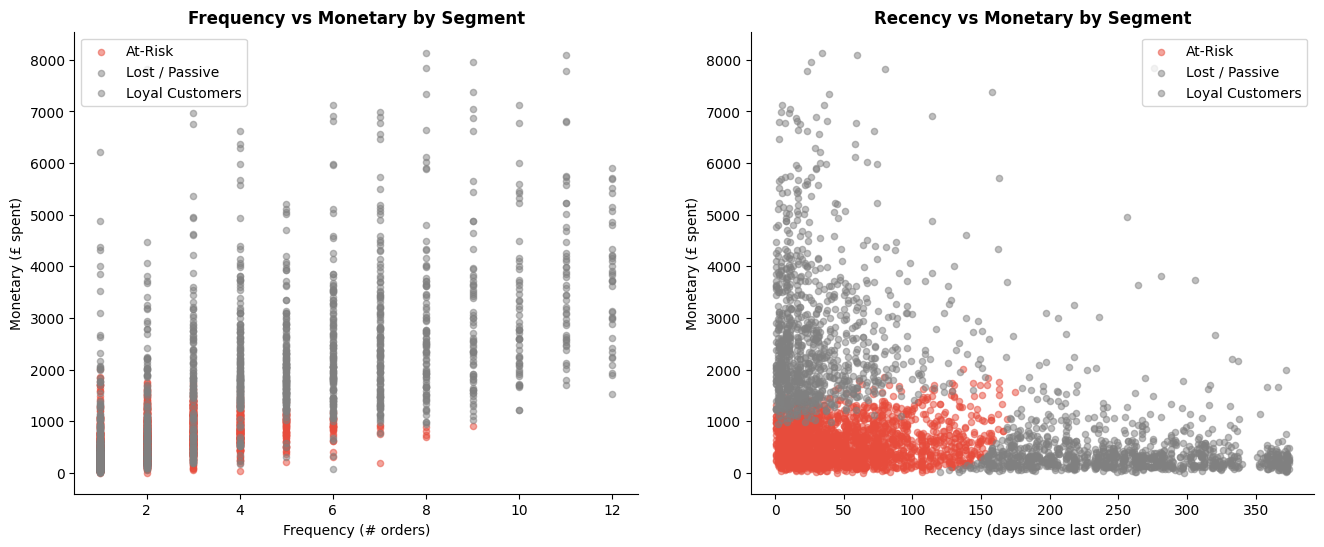

In [33]:
# 2D Frequency vs Monetary coloured by Segment
seg_colors = {
    'High-Value' : '#2ECC71',
    'Regular'    : '#3498DB',
    'Occasional' : '#E67E22',
    'At-Risk'    : '#E74C3C'
}

# Cap outliers for cleaner plot
plot_rfm = rfm.copy()
plot_rfm = plot_rfm[plot_rfm['Monetary']  < plot_rfm['Monetary'].quantile(0.97)]
plot_rfm = plot_rfm[plot_rfm['Frequency'] < plot_rfm['Frequency'].quantile(0.97)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for seg, grp in plot_rfm.groupby('Segment'):
    c = seg_colors.get(seg, 'gray')
    axes[0].scatter(grp['Frequency'], grp['Monetary'],
                    label=seg, alpha=0.5, s=20, color=c)
    axes[1].scatter(grp['Recency'], grp['Monetary'],
                    label=seg, alpha=0.5, s=20, color=c)

axes[0].set_xlabel('Frequency (# orders)'); axes[0].set_ylabel('Monetary (£ spent)')
axes[0].set_title('Frequency vs Monetary by Segment', fontsize=12, fontweight='bold')
axes[0].legend(); axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

axes[1].set_xlabel('Recency (days since last order)'); axes[1].set_ylabel('Monetary (£ spent)')
axes[1].set_title('Recency vs Monetary by Segment', fontsize=12, fontweight='bold')
axes[1].legend(); axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)



In [34]:
plt.suptitle('Customer Cluster Profiles', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved cluster_scatter.png')

<Figure size 640x480 with 0 Axes>

Saved cluster_scatter.png


In [42]:
from sklearn.metrics.pairwise import cosine_similarity
import pickle

# ── Build Customer × Product pivot (purchase count per product per customer) ─
# Keep top N products to avoid memory issues (541K rows × all unique products)
TOP_N_PRODUCTS = 200  # increase if your Colab RAM allows

top_prod_list = (
    df_clean.groupby('Description')['Quantity'].sum()
    .sort_values(ascending=False)
    .head(TOP_N_PRODUCTS)
    .index.tolist()
)

df_top = df_clean[df_clean['Description'].isin(top_prod_list)]

# Pivot: rows = CustomerID, columns = Product Description, values = sum of Quantity
customer_product_matrix = (
    df_top.pivot_table(
        index='CustomerID',
        columns='Description',
        values='Quantity',
        aggfunc='sum'
    ).fillna(0)
)

print(f'Matrix shape: {customer_product_matrix.shape}')
print(f'  → {customer_product_matrix.shape[0]:,} customers × {customer_product_matrix.shape[1]} products')
print('Customer-Product matrix ready')

Matrix shape: (4090, 200)
  → 4,090 customers × 200 products
Customer-Product matrix ready


In [36]:
# Transpose → Product × Customer, then compute cosine similarity
product_matrix = customer_product_matrix.T  # shape: products × customers

cosine_sim = cosine_similarity(product_matrix)

# Wrap in DataFrame for easy lookup
cosine_sim_df = pd.DataFrame(
    cosine_sim,
    index=product_matrix.index,
    columns=product_matrix.index
)

print(f'Similarity matrix shape: {cosine_sim_df.shape}')
print(f'Sample (top-left 3×3):')
print(cosine_sim_df.iloc[:3, :3].round(3))
print('\n Cosine similarity matrix computed')

Similarity matrix shape: (500, 500)
Sample (top-left 3×3):
Description                        SET 2 TEA TOWELS I LOVE LONDON   \
Description                                                          
 SET 2 TEA TOWELS I LOVE LONDON                              1.000   
10 COLOUR SPACEBOY PEN                                       0.009   
12 PENCIL SMALL TUBE WOODLAND                                0.001   

Description                       10 COLOUR SPACEBOY PEN  \
Description                                                
 SET 2 TEA TOWELS I LOVE LONDON                    0.009   
10 COLOUR SPACEBOY PEN                             1.000   
12 PENCIL SMALL TUBE WOODLAND                      0.558   

Description                       12 PENCIL SMALL TUBE WOODLAND  
Description                                                      
 SET 2 TEA TOWELS I LOVE LONDON                           0.001  
10 COLOUR SPACEBOY PEN                                    0.558  
12 PENCIL SMALL TUBE WOOD

In [37]:
def get_recommendations(product_name: str, top_n: int = 5) -> pd.DataFrame:
    """
    Given a product name (exact or partial match),
    return top_n most similar products using cosine similarity.
    """
    # Find closest match (case-insensitive)
    all_products = cosine_sim_df.index.tolist()
    matches = [p for p in all_products if product_name.upper() in p.upper()]

    if not matches:
        return pd.DataFrame({'Message': [f'No product found matching "{product_name}"']})

    matched_product = matches[0]  # take first match
    print(f'📌 Matched product: "{matched_product}"')

    # Get similarity scores, drop itself, sort descending
    sim_scores = (
        cosine_sim_df[matched_product]
        .drop(index=matched_product)
        .sort_values(ascending=False)
        .head(top_n)
        .reset_index()
    )
    sim_scores.columns = ['Product', 'Similarity Score']
    sim_scores['Similarity Score'] = sim_scores['Similarity Score'].round(4)
    sim_scores.index = range(1, top_n + 1)
    return sim_scores


# Test with a sample product
sample = top_prod_list[0]
print(f'Testing with: "{sample}"\n')
recs = get_recommendations(sample, top_n=5)
print(recs.to_string())
print('\n Recommendation function working')

Testing with: "PAPER CRAFT , LITTLE BIRDIE"

📌 Matched product: "PAPER CRAFT , LITTLE BIRDIE"
                            Product  Similarity Score
1   ZINC T-LIGHT HOLDER STARS SMALL               0.0
2   SET 2 TEA TOWELS I LOVE LONDON                0.0
3            10 COLOUR SPACEBOY PEN               0.0
4            WRAP CHRISTMAS VILLAGE               0.0
5              WRAP ALPHABET DESIGN               0.0

 Recommendation function working


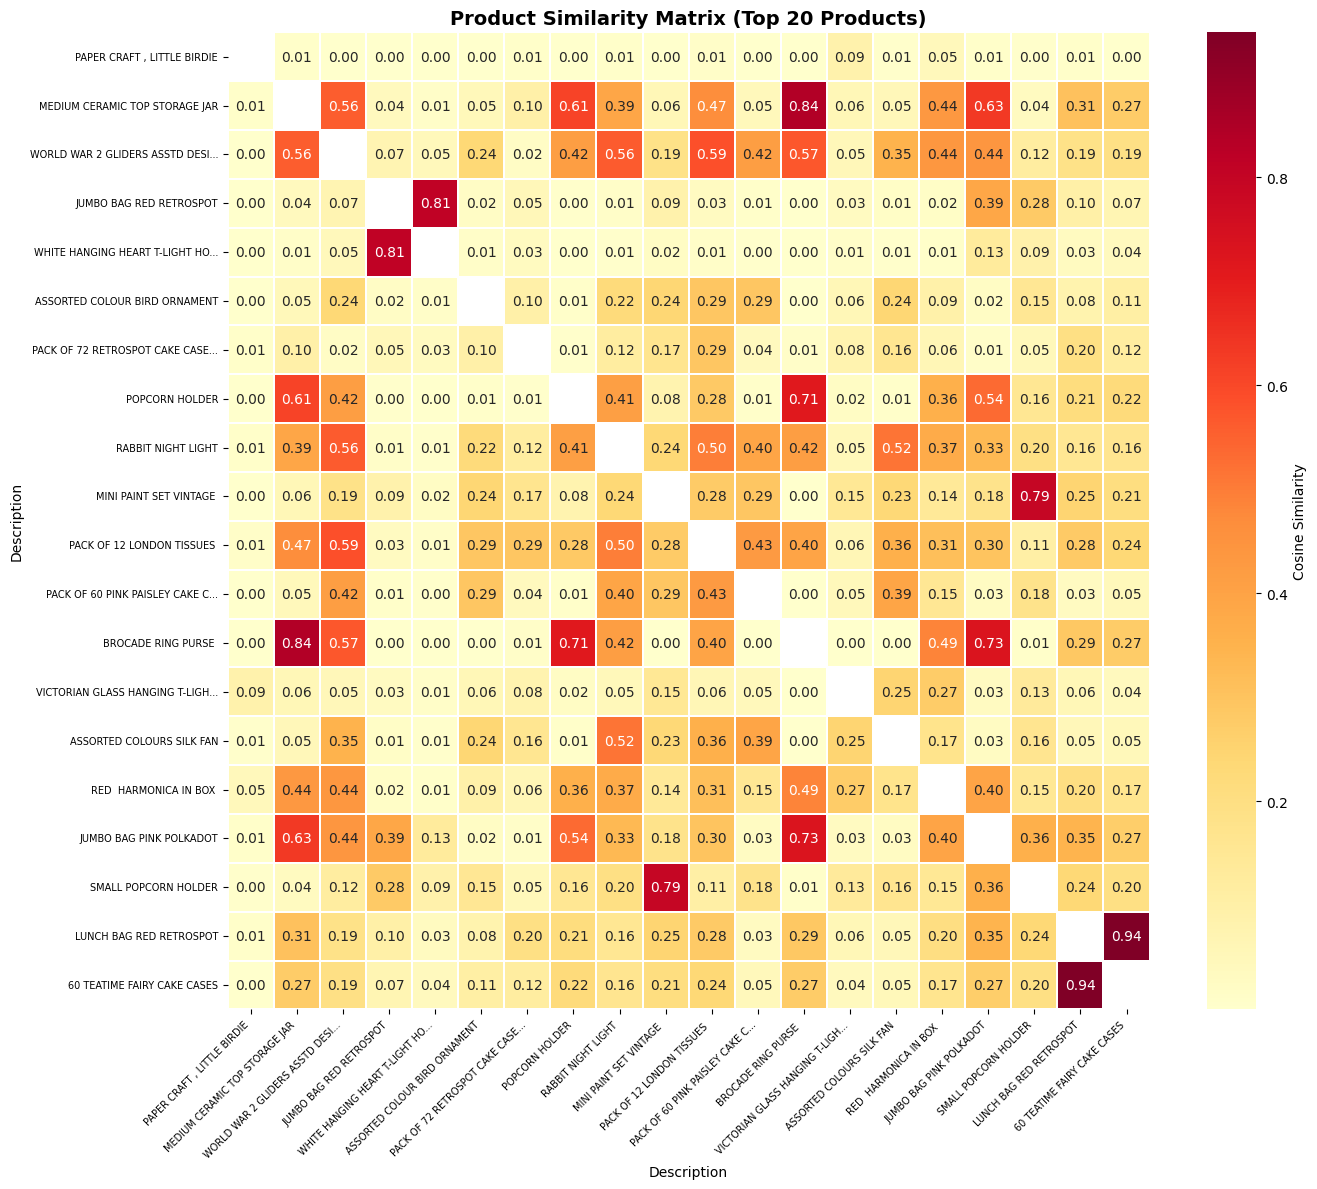

Saved similarity_heatmap.png


In [38]:
# Visualise similarity for top 20 products
TOP_HEAT = 20
heat_labels = [p[:30] + '...' if len(p) > 30 else p for p in top_prod_list[:TOP_HEAT]]
heat_matrix = cosine_sim_df.iloc[:TOP_HEAT, :TOP_HEAT]

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.eye(TOP_HEAT, dtype=bool)  # mask diagonal (self-similarity = 1)

sns.heatmap(
    heat_matrix,
    xticklabels=heat_labels,
    yticklabels=heat_labels,
    mask=mask,
    cmap='YlOrRd',
    annot=True,
    fmt='.2f',
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Cosine Similarity'},
    ax=ax
)

ax.set_title(f'Product Similarity Matrix (Top {TOP_HEAT} Products)', fontsize=14, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)

plt.tight_layout()
plt.savefig('similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved similarity_heatmap.png')

In [39]:
import pickle

# 1. KMeans model (already fitted in Part 1 as final_km)
with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(final_km, f)

# 2. Scaler (already fitted in Part 1 as scaler)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# 3. Segment label map  {cluster_int: 'High-Value', ...}
with open('segment_labels.pkl', 'wb') as f:
    pickle.dump(segment_labels, f)

# 4. Cosine similarity DataFrame
with open('cosine_sim_df.pkl', 'wb') as f:
    pickle.dump(cosine_sim_df, f)

# 5. Product list (for dropdown in Streamlit)
with open('product_list.pkl', 'wb') as f:
    pickle.dump(top_prod_list, f)

# 6. RFM with segments (for quick lookups)
rfm.to_csv('rfm_segments.csv', index=False)

print('Saved:')
for f in ['kmeans_model.pkl','scaler.pkl','segment_labels.pkl',
          'cosine_sim_df.pkl','product_list.pkl','rfm_segments.csv']:
    print(f'  {f}')

Saved:
  kmeans_model.pkl
  scaler.pkl
  segment_labels.pkl
  cosine_sim_df.pkl
  product_list.pkl
  rfm_segments.csv


In [40]:
from google.colab import files

download_files = [
    # Models
    'kmeans_model.pkl', 'scaler.pkl', 'segment_labels.pkl',
    'cosine_sim_df.pkl', 'product_list.pkl', 'rfm_segments.csv',
    # Charts
    'eda_country.png', 'eda_top_products.png', 'eda_trends.png',
    'eda_monetary.png', 'cluster_scatter.png', 'similarity_heatmap.png',
    'rfm_distributions.png', 'elbow_silhouette.png',
    'segment_counts.png', 'rfm_radar.png'
]

for fname in download_files:
    try:
        files.download(fname)
        print(f'  {fname}')
    except Exception as e:
        print(f'Skipped {fname}: {e}')

print('\n All files downloaded — put them in your Streamlit app folder')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  kmeans_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  segment_counts.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  rfm_radar.png

 All files downloaded — put them in your Streamlit app folder


In [41]:
seg_summary = rfm.groupby('Segment').agg(
    Customers  = ('CustomerID','count'),
    Avg_Recency= ('Recency','mean'),
    Avg_Freq   = ('Frequency','mean'),
    Avg_Spend  = ('Monetary','mean')
).round(1).reset_index()

print('='*65)
print('         SHOPPER SPECTRUM — FINAL SEGMENT SUMMARY')
print('='*65)
print(seg_summary.to_string(index=False))
print('='*65)
print(f'Total customers segmented : {len(rfm):,}')
print(f'Total products indexed    : {len(top_prod_list):,}')
print(f'Similarity matrix size    : {cosine_sim_df.shape[0]}×{cosine_sim_df.shape[1]}')
print('='*65)
print('FILES READY FOR STREAMLIT:')
print('  kmeans_model.pkl   → cluster prediction')
print('  scaler.pkl         → scale user R/F/M inputs')
print('  segment_labels.pkl → map cluster int → segment name')
print('  cosine_sim_df.pkl  → product recommendations')
print('  product_list.pkl   → dropdown product list')
print('='*65)

         SHOPPER SPECTRUM — FINAL SEGMENT SUMMARY
        Segment  Customers  Avg_Recency  Avg_Freq  Avg_Spend
        At-Risk       2059         53.0       2.2      586.9
      Champions         22          5.8      77.5    76791.6
 Lost / Passive       1004        253.4       1.5      408.6
Loyal Customers       1253         30.2       8.7     4471.9
Total customers segmented : 4,338
Total products indexed    : 500
Similarity matrix size    : 500×500
FILES READY FOR STREAMLIT:
  kmeans_model.pkl   → cluster prediction
  scaler.pkl         → scale user R/F/M inputs
  segment_labels.pkl → map cluster int → segment name
  cosine_sim_df.pkl  → product recommendations
  product_list.pkl   → dropdown product list
